<a href="https://colab.research.google.com/github/marioarsw/AnaliticaDescriptiva/blob/main/practicas/267379_01_semana11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Maestría en Inteligencia Artificial y Analítica de Datos


*   Curso: Programación para Analítica Descriptiva y Predictiva
*   Semestre: Enero-Junio
*   Profesor: Dr. Vicente García Jiménez



## Mario Amador - 267370.

### Objetivo de aprendizaje
Al finalizar esta práctica, el estudiante será capaz de aplicar regresión lineal múltiple utilizando Scikit-Learn para modelar la relación entre varias variables independientes y una variable dependiente, verificar los supuestos del modelo, interpretar los coeficientes, analizar la correlación entre predictores y evaluar el rendimiento del modelo utilizando métricas como el MSE, RMSE y R².

### Datos

Trabajarás con el archivo advertising.csv, que contiene información sobre el gasto publicitario en diferentes medios y las ventas obtenidas:

**TV:** inversión en publicidad televisiva.

**Radio:** inversión en publicidad en radio.

**Newspaper:** inversión en publicidad en periódicos.

**Sales:** ventas del producto (variable dependiente).

# Parte 1: Carga de datos y bibliotecas

* Importa las bibliotecas necesarias

* Carga el archivo *advertising.csv.*

* Muestra las primeras filas del dataframe.

* Describe estadísticamente las variables.

In [5]:
# Importar bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas para regresión
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Bibliotecas estadísticas
import statsmodels.api as sm
from scipy import stats

# Para VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
df = pd.read_csv('/content/drive/MyDrive/ClassFiles/Unidad03/advertising.csv')

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [8]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


###  Exploración inicial de datos


In [9]:
# Valores faltantes
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [10]:
# Porcentaje de los valores nulos
(df.isnull().sum() / len(df)) * 100

,0
TV,0.0
Radio,0.0
Newspaper,0.0
Sales,0.0


In [11]:
# Tipos de datos
df.dtypes

,0
TV,float64
Radio,float64
Newspaper,float64
Sales,float64


In [12]:
# Estadísticas descriptivas
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [13]:
# Ver duplicados
df.duplicated().sum()

np.int64(0)

In [14]:
pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.5 MB/s eta 0:00:00


In [15]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Advertising Dataset Profiling Report")

/tmp/ipykernel_3955/3674307063.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [16]:
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 4/4 [00:00<00:00, 91.81it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# Parte 2: Análisis exploratorio de los datos

### 2.1. Análisis de la Relación Lineal entre la variable dependiente y las independientes

* Realiza gráficos de dispersión entre cada variable independiente (TV, Radio, Newspaper) y la variable dependiente (Sales). Usa también regplot.

* ¿Qué relación observas entre cada predictor y las ventas?

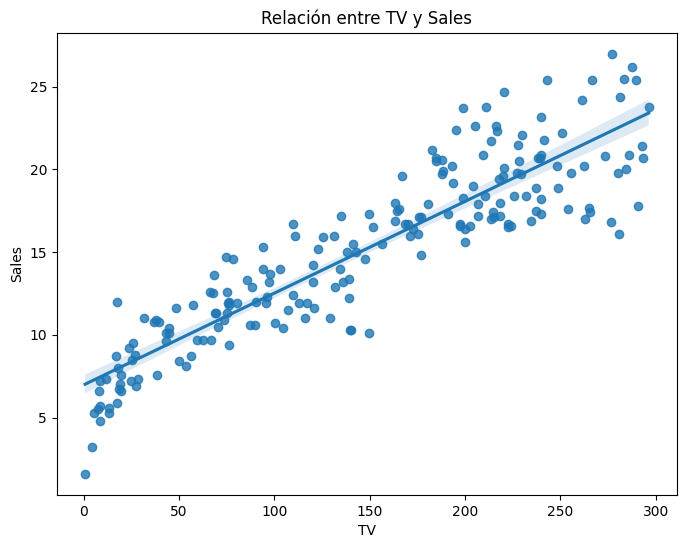

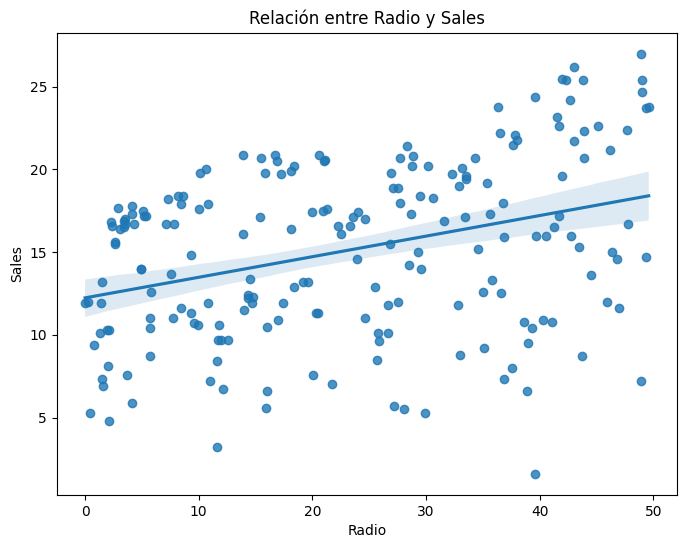

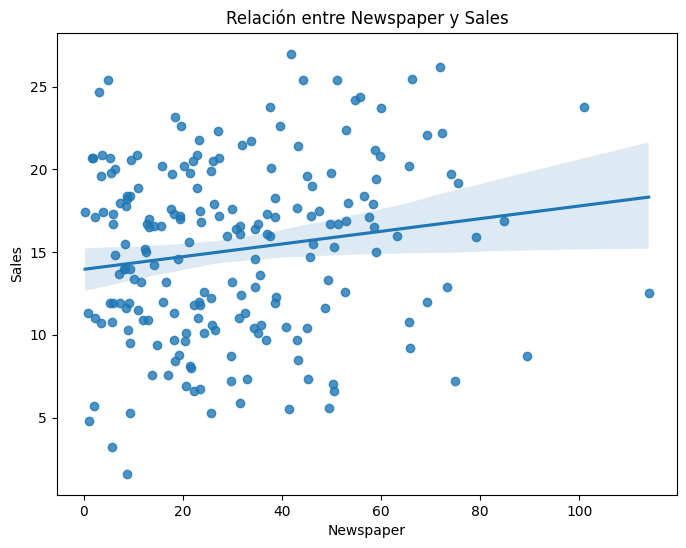

In [17]:
# ============================================
# PARTE 2.1
# Relación lineal entre variables independientes y Sales
# ============================================

variables = ['TV', 'Radio', 'Newspaper']

for var in variables:
    plt.figure(figsize=(8,6))
    sns.regplot(x=df[var], y=df['Sales'])

    plt.title(f'Relación entre {var} y Sales')
    plt.xlabel(var)
    plt.ylabel("Sales")
    plt.show()

#### Interpretación

Al observar los gráficos de dispersión con línea de regresión, se puede notar que la variable TV tiene la relación lineal más fuerte con las ventas, seguida de Radio.

Ambas muestran una tendencia positiva clara: a mayor inversión publicitaria, mayores ventas.

Por otro lado, Newspaper presenta una relación más débil y dispersa, lo que sugiere que su capacidad predictiva sobre Sales es menor.

Esto indica que TV y Radio podrían ser variables más importantes dentro del modelo de regresión.

# 2.2 Correlación entre variables

*   Calcula la matriz de correlación entre todas las variables

*   Visualízala con un mapa de calor.

*   Responde:

    *   ¿Cuál variable tiene mayor correlación con Sales?

    *   ¿Hay correlación alta entre predictores?

Matriz de correlación:


,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


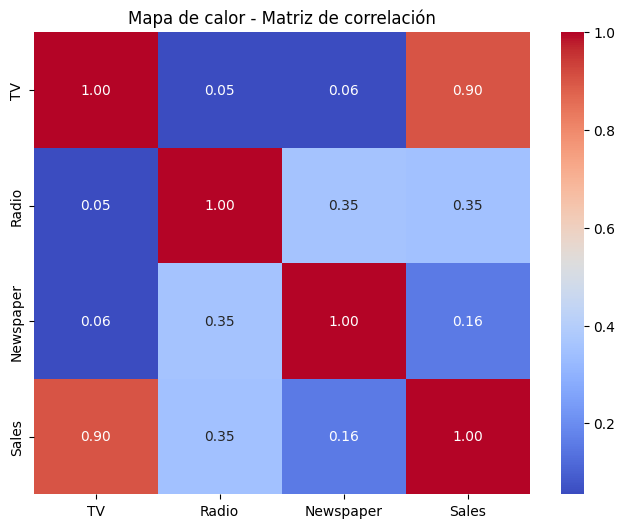

In [18]:
# ============================================
# PARTE 2.2
# Matriz de correlación
# ============================================

# Matriz de correlación
corr_matrix = df.corr()

print("Matriz de correlación:")
display(corr_matrix)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Mapa de calor - Matriz de correlación")
plt.show()

#### Análisis de la Matriz de Correlación:

Una vez ejecutado el mapa de calor, podrás observar lo siguiente:

*   **¿Cuál variable tiene mayor correlación con Sales?**
    Observando la fila (o columna) correspondiente a 'Sales', la variable 'TV' presentará la correlación positiva más alta, indicando una fuerte relación lineal directa entre la inversión en publicidad televisiva y las ventas.

*   **¿Hay correlación alta entre predictores?**
    Al analizar las correlaciones entre las variables independientes ('TV', 'Radio', 'Newspaper'), se espera que las correlaciones sean moderadas. Por ejemplo, 'Radio' y 'Newspaper' podrían tener una correlación baja a moderada entre sí, y lo mismo para 'TV' con 'Radio' o 'Newspaper'. Generalmente, las correlaciones no deberían ser extremadamente altas (cercanas a 1 o -1), lo que es deseable para evitar problemas de multicolinealidad en un modelo de regresión lineal múltiple. Si los coeficientes son menores a 0.8 o 0.9, se considera que no hay un problema grave de multicolinealidad.

# Parte 3. Multicolinealidad

* Calcula el VIF (Variance Inflation Factor) para cada variable independiente.
* Crea un diagrama de barras  para mostrar el  VIF
* Interpreta los resultados:
  * ¿Alguna variable tiene un VIF mayor a 5 o mayor a 10?
  * ¿Qué implicaciones tiene esto para el modelo?

### ¿Qué es la Multicolinealidad?

La multicolinealidad ocurre cuando dos o más variables independientes están altamente correlacionadas entre sí.

Esto puede generar problemas en el modelo de regresión, como:

* Coeficientes inestables
* Dificultad para interpretar el impacto real de cada variable
* Aumento en la varianza de los coeficientes
* Menor confiabilidad estadística

Para detectar este problema se utiliza el VIF (Variance Inflation Factor).

**Interpretación del VIF**
* VIF ≈ 1 → no hay multicolinealidad
* VIF entre 1 y 5 → multicolinealidad moderada (aceptable)
* VIF > 5 → posible problema
* VIF > 10 → problema serio de multicolinealidad

Se calculará el VIF para:

* TV
* Radio
* Newspaper

y posteriormente se mostrará mediante un gráfico de barras.

### ¿Qué es el VIF (Factor de Inflación de la Varianza)?

El **Factor de Inflación de la Varianza (VIF)** es una métrica que se utiliza para detectar y cuantificar la severidad de la multicolinealidad en un modelo de regresión lineal múltiple. Mide cuánto se ha inflado la varianza de un coeficiente de regresión estimado debido a la colinealidad con otras variables predictoras en el modelo.

**¿Cómo se calcula el VIF?**

Para cada variable predictora $X_i$, el VIF se calcula ajustando un modelo de regresión lineal en el que $X_i$ es la variable dependiente y todas las demás variables predictoras del modelo original son las independientes. La fórmula es:

$$ VIF_i = \frac{1}{1 - R_i^2} $$

Donde $R_i^2$ es el coeficiente de determinación (R-cuadrado) de esa regresión auxiliar. Un $R_i^2$ alto significa que $X_i$ puede ser bien predicha por las otras variables, indicando alta colinealidad y un VIF alto.

In [19]:
# ============================================
# PARTE 3
# Cálculo de VIF
# ============================================

# Variables independientes
X = df[['TV', 'Radio', 'Newspaper']]

# Agregar constante para cálculo de VIF
X_vif = sm.add_constant(X)

# Calcular VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print("Tabla de VIF:")
display(vif_data)

Tabla de VIF:


,Variable,VIF
0,const,6.848900
1,TV,1.004611
2,Radio,1.144952
3,Newspaper,1.145187


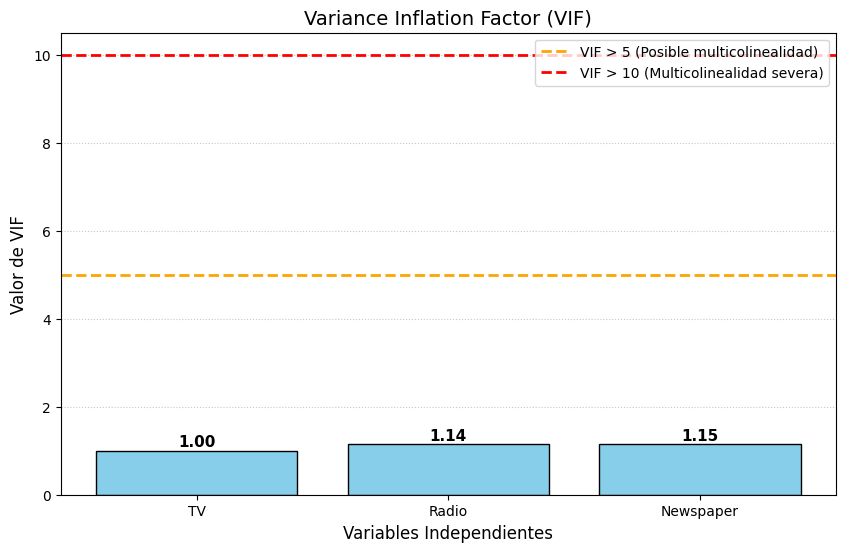

In [20]:
# ============================================
# Gráfico de barras del VIF
# ============================================

# Excluir constante para visualizar mejor
vif_plot = vif_data[vif_data["Variable"] != "const"]

plt.figure(figsize=(10,6))

# Colores personalizados según nivel de VIF
colors = []

for valor in vif_plot["VIF"]:
    if valor < 5:
        colors.append("skyblue")   # Sin problema
    elif valor < 10:
        colors.append("orange")    # Atención
    else:
        colors.append("red")       # Multicolinealidad severa

# Gráfico de barras
bars = plt.bar(
    vif_plot["Variable"],
    vif_plot["VIF"],
    color=colors,
    edgecolor="black"
)

# Línea umbral VIF = 5
plt.axhline(
    y=5,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="VIF > 5 (Posible multicolinealidad)"
)

# Línea umbral VIF = 10
plt.axhline(
    y=10,
    color="red",
    linestyle="--",
    linewidth=2,
    label="VIF > 10 (Multicolinealidad severa)"
)

# Mostrar valor encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        f"{height:.2f}",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Variance Inflation Factor (VIF)", fontsize=14)
plt.xlabel("Variables Independientes", fontsize=12)
plt.ylabel("Valor de VIF", fontsize=12)

plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.show()

# Parte 4: Construcción del Modelo (Todas las variables Independientes), Evaluación

### 4.1 Entrenamiento del Modelo

* Entrena un modelo de regresión lineal múltiple usando TV, Radio y Newspaper como variables independientes.
* Imprime el intercepto y los coeficientes del modelo.
* Interpreta cada uno:
  *¿Qué significa cada uno de los coeficientes  en términos de ventas?

En esta etapa se construye el modelo de regresión lineal múltiple utilizando las tres variables independientes:

* TV
* Radio
* Newspaper

Para predecir la variable dependiente:

* Sales

Con este modelo buscamos encontrar la ecuación:

$$Sales=β0​+β1​(TV)+β2​(Radio)+β3​(Newspaper)$$

Donde:

* β₀ es el intercepto
* β₁, β₂ y β₃ son los coeficientes de cada variable independiente

Cada coeficiente indica cuánto cambian las ventas cuando aumenta una unidad de inversión en esa variable, manteniendo constantes las demás.

In [21]:
# ============================================
# PARTE 4.1
# Entrenamiento del modelo de regresión múltiple
# ============================================

# Variables independientes
X = df[['TV', 'Radio', 'Newspaper']]

# Variable dependiente
y = df['Sales']

# División de datos entrenamiento / prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Crear modelo
modelo = LinearRegression()

# Entrenar modelo
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)

# Intercepto
print("Intercepto del modelo:")
print(modelo.intercept_)

# Coeficientes
print("\nCoeficientes del modelo:")
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo.coef_
})

display(coeficientes)

Intercepto del modelo:
4.714126402214127

Coeficientes del modelo:


,Variable,Coeficiente
0,TV,0.054509
1,Radio,0.100945
2,Newspaper,0.004337


## Interpretación

### Intercepto

El intercepto del modelo es 4.7141, lo que significa que si la inversión en TV, Radio y Newspaper fuera igual a cero, el modelo estima que las ventas serían aproximadamente de 4.71 unidades.

Aunque en la práctica no suele existir un escenario real con inversión cero en todos los medios, este valor funciona como el punto base de predicción del modelo.

### Coeficiente de TV

El coeficiente de TV es 0.0545, lo que indica que por cada unidad adicional invertida en publicidad televisiva, las ventas aumentan aproximadamente en 0.054 unidades, manteniendo constantes Radio y Newspaper.

Esto muestra que la publicidad en televisión tiene un efecto positivo sobre las ventas.

### Coeficiente de Radio

El coeficiente de Radio es 0.1009, lo que significa que por cada unidad adicional invertida en publicidad en radio, las ventas aumentan aproximadamente en 0.10 unidades, manteniendo constantes TV y Newspaper.

Este es el coeficiente más alto del modelo, lo que sugiere que Radio tiene el mayor impacto individual sobre las ventas dentro de este análisis.

### Coeficiente de Newspaper

El coeficiente de Newspaper es 0.0043, lo que indica que por cada unidad adicional invertida en publicidad en periódicos, las ventas aumentan únicamente en 0.004 unidades, manteniendo constantes TV y Radio.

Este valor es considerablemente menor que los anteriores, lo que sugiere que Newspaper tiene una influencia muy baja sobre las ventas.

Esto puede indicar que esta variable aporta poca capacidad predictiva al modelo y posteriormente deberá verificarse su significancia estadística mediante los p-values en statsmodels.

# 4.2 Normalidad de los residuos

* Calcula los residuos: residuos = y - y_pred.

* Grafica un histograma con KDE de los residuos.

* ¿Los residuos parecen distribuirse normalmente?

### Explicación

Uno de los supuestos importantes de la regresión lineal múltiple es que los residuos del modelo sigan aproximadamente una distribución normal.

Los residuos representan la diferencia entre los valores reales y los valores predichos por el modelo:


  Residuo = y-ŷ


Donde:

* y = valor real de Sales
* ŷ = valor predicho por el modelo

Si los residuos se distribuyen normalmente, significa que el modelo está capturando adecuadamente la relación entre las variables y que los errores no presentan sesgos importantes.

Para verificar esto, se construye un histograma acompañado de una curva KDE (Kernel Density Estimate), que permite visualizar mejor la forma de la distribución.

Una distribución aproximadamente simétrica y con forma de campana sugiere normalidad.

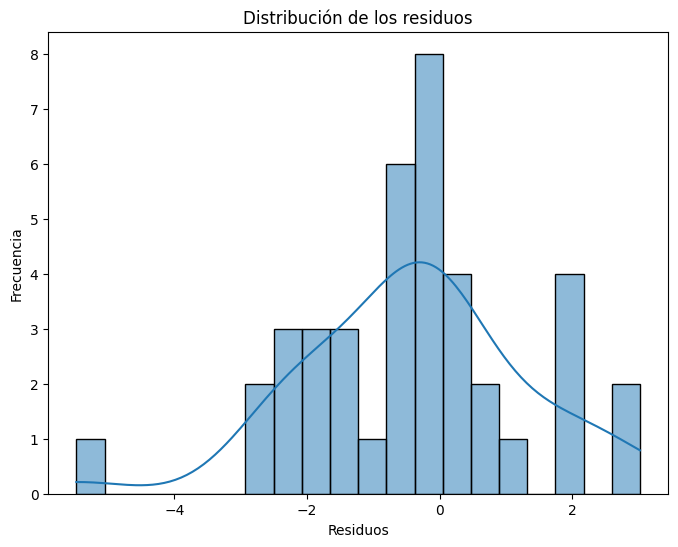

In [22]:
# ============================================
# PARTE 4.2
# Normalidad de los residuos
# ============================================

# Calcular residuos
residuos = y_test - y_pred

# Histograma con KDE
plt.figure(figsize=(8,6))
sns.histplot(
    residuos,
    kde=True,
    bins=20
)

plt.title("Distribución de los residuos")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.show()

### Interpretación

Al observar el histograma de los residuos junto con la curva KDE, se puede notar que la mayoría de los residuos se concentran alrededor de cero, lo cual es una buena señal para el modelo de regresión.

La distribución presenta una forma aproximadamente similar a una campana, aunque no es perfectamente simétrica, ya que se observan algunas desviaciones hacia los extremos, especialmente hacia los valores negativos.

Esto sugiere que los residuos siguen una normalidad aceptable, aunque no perfecta, lo cual suele ser suficiente en modelos de regresión lineal para continuar con el análisis.

La presencia de algunos valores alejados puede indicar la existencia de ciertos errores de predicción más grandes o posibles valores atípicos, pero en general no parece haber una violación grave del supuesto de normalidad.

Por lo tanto, se puede concluir que el modelo cumple razonablemente con el supuesto de normalidad de los residuos, permitiendo confiar en la validez estadística de la regresión y en la interpretación de sus coeficientes.

# 4.3. Homocedasticidad

* Grafica los residuos contra los valores predichos.
* ¿Observas patrones? ¿Los residuos se dispersan aleatoriamente?

### Explicación

Otro supuesto importante en la regresión lineal múltiple es la homocedasticidad, que significa que la varianza de los residuos debe mantenerse aproximadamente constante para todos los niveles de predicción.

En otras palabras, los errores del modelo deben tener una dispersión similar sin importar si las ventas predichas son bajas o altas.

Para verificar este supuesto, se realiza una gráfica de:

* Valores predichos (ŷ)

vs

* Residuos (y - ŷ)

Si los puntos se dispersan de forma aleatoria alrededor de la línea horizontal en cero, se considera que existe homocedasticidad.

Si aparecen patrones claros como:

* Forma de embudo
* Curvas
* Agrupaciones sistemáticas

podría existir **heterocedasticidad**, lo que indicaría problemas en el modelo.

La homocedasticidad es importante porque permite que las estimaciones y pruebas estadísticas del modelo sean más confiables.

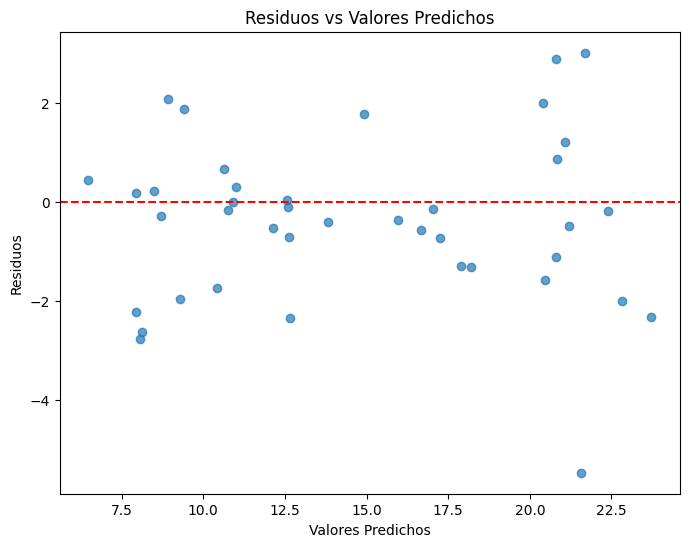

In [23]:
# ============================================
# PARTE 4.3
# Homocedasticidad
# ============================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuos,
    alpha=0.7
)

# Línea horizontal en cero
plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title("Residuos vs Valores Predichos")
plt.xlabel("Valores Predichos")
plt.ylabel("Residuos")
plt.show()

### Interpretación

Al observar la gráfica de residuos contra valores predichos, se aprecia que los puntos se encuentran distribuidos alrededor de la línea horizontal en cero, sin seguir un patrón claramente definido como una curva o una forma de embudo muy marcada.

Esto es una señal positiva, ya que sugiere que los residuos se dispersan de manera relativamente aleatoria y que la varianza de los errores se mantiene bastante constante a lo largo de los distintos niveles de predicción.

Sin embargo, también se observan algunos puntos más alejados, especialmente en valores predichos altos, donde existen residuos tanto positivos como negativos más extremos. Esto puede indicar la presencia de algunos valores atípicos o cierta variabilidad mayor en esa zona.

A pesar de esto, no se detecta una heterocedasticidad severa que comprometa el modelo de forma importante.

Por lo tanto, se puede concluir que el supuesto de homocedasticidad se cumple de manera razonablemente aceptable, lo que fortalece la validez estadística del modelo de regresión lineal múltiple.

# 4.4 Q-Q Plot

* Graficar el Q-Q Plot
* Interpreta el gráfico:

  * Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal.

  * Desviaciones sistemáticas indican asimetría o colas pesadas.

### Explicación

El Q-Q Plot (Quantile-Quantile Plot) es una herramienta gráfica que permite verificar si los residuos del modelo siguen una distribución normal.

Este gráfico compara:

* Los cuantiles teóricos de una distribución normal

vs

* Los cuantiles observados de los residuos

La interpretación principal es:

* Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal.
* Si existen desviaciones sistemáticas de esa línea, puede haber asimetría, colas pesadas o problemas de normalidad.

Este análisis complementa el histograma de residuos realizado anteriormente y permite una validación más visual y precisa del supuesto de normalidad.

Cumplir este supuesto fortalece la confiabilidad de las pruebas estadísticas del modelo de regresión.

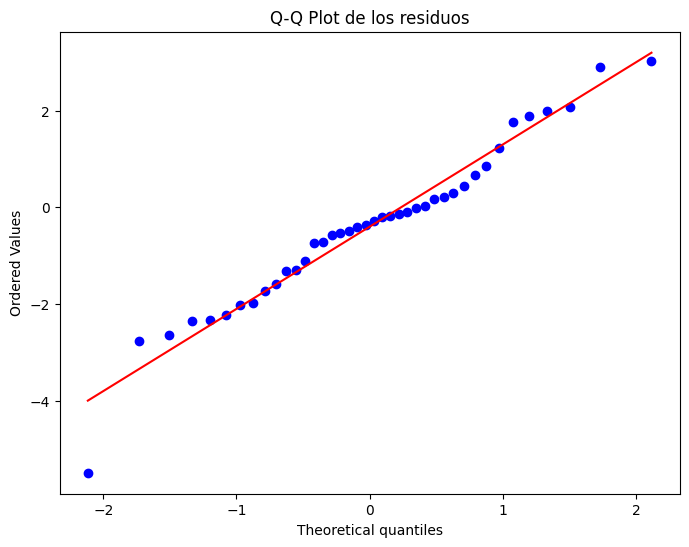

In [24]:
# ============================================
# PARTE 4.4
# Q-Q Plot
# ============================================

import scipy.stats as stats

plt.figure(figsize=(8,6))


stats.probplot(
    residuos,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot de los residuos")
plt.show()

Al observar el Q-Q Plot de los residuos, se puede notar que la mayoría de los puntos se alinean de forma bastante cercana a la línea diagonal roja, especialmente en la zona central de la gráfica.

Esto indica que los residuos siguen aproximadamente una distribución normal, lo cual es una señal positiva para el modelo de regresión lineal múltiple.

Sin embargo, también se observan algunas desviaciones en los extremos, principalmente en la parte inferior izquierda, donde aparece un punto más alejado de la línea. Esto sugiere la posible presencia de algunos valores atípicos o ligeras desviaciones de normalidad en las colas de la distribución.

A pesar de estas pequeñas desviaciones, no se aprecia una ruptura severa del supuesto de normalidad, ya que el comportamiento general sigue siendo bastante alineado con la distribución normal teórica.

Por lo tanto, se puede concluir que el supuesto de normalidad de los residuos se cumple de manera aceptable, lo que fortalece la validez estadística del modelo y permite continuar con confianza en la interpretación de los resultados.

# 4.5. Evaluación del Modelo

* Calcula las métricas:

  * MSE (error cuadrático medio)

  * RMSE (raíz del error cuadrático medio)

  * R² (coeficiente de determinación)

* ¿Qué nos dicen estas métricas sobre el ajuste del modelo?

### Explicación

Después de entrenar el modelo de regresión lineal múltiple, es necesario evaluar qué tan bien está realizando las predicciones.

Para ello se utilizan tres métricas principales:

### MSE (Mean Squared Error)

El MSE mide el promedio de los errores al cuadrado entre los valores reales y los valores predichos.

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

Mientras más pequeño sea el MSE, mejor será el ajuste del modelo.

---

### RMSE (Root Mean Squared Error)

Es la raíz cuadrada del MSE y permite interpretar el error en las mismas unidades que la variable dependiente.

$$
RMSE = \sqrt{MSE}
$$

También, mientras menor sea, mejor será el modelo.

---

### R² (Coeficiente de determinación)

Mide qué porcentaje de la variabilidad de la variable dependiente puede ser explicado por el modelo.

$$
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
$$

Su valor va de 0 a 1:

- cercano a 1 → excelente ajuste  
- cercano a 0 → mal ajuste

Un R² alto indica que el modelo explica bien las ventas.

In [25]:
# ============================================
# PARTE 4.5
# Evaluación del modelo
# ============================================

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calcular métricas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 2.9077569102710896
RMSE: 1.7052146229349223
R²: 0.9059011844150826


### Interpretación

Con los resultados obtenidos:

* MSE = 2.9078
* RMSE = 1.7052
* R² = 0.9059

se puede concluir que el modelo de regresión lineal múltiple presenta un muy buen ajuste.


El valor de MSE es relativamente bajo, lo que indica que la diferencia promedio entre los valores reales y los valores predichos no es grande.


El RMSE = 1.70 permite interpretar el error promedio en las mismas unidades de la variable Sales, lo que significa que, en promedio, las predicciones del modelo se desvían aproximadamente 1.7 unidades respecto a las ventas reales.


Por otro lado, el valor de R² = 0.9059 indica que aproximadamente el 90.59% de la variabilidad de las ventas (Sales) puede ser explicada por las variables independientes TV, Radio y Newspaper.


Este es un resultado bastante alto, lo que demuestra que el modelo tiene una excelente capacidad predictiva y que las variables publicitarias explican gran parte del comportamiento de las ventas.


Por lo tanto, se puede afirmar que el modelo construido es estadísticamente sólido, confiable y adecuado para realizar predicciones sobre las ventas.


# 4.6. Visualización de Predicciones

* Crea un gráfico comparando Sales reales vs Sales predichas.

* Puedes usar plt.scatter(y_true, y_pred) para evaluar visualmente el ajuste.

* ¿Qué observas? ¿Qué información puedes obtener de esta gráfica?

### Explicación

Una forma visual de evaluar el rendimiento del modelo de regresión es comparar los valores reales de la variable dependiente (Sales) con los valores predichos por el modelo.

Para ello se utiliza un gráfico de dispersión donde:

* eje X → valores reales (y_test)
* eje Y → valores predichos (y_pred)

Además, se agrega una línea diagonal de referencia que representa el caso ideal donde:

* y = ŷ
	​
Es decir, cuando la predicción coincide exactamente con el valor real.

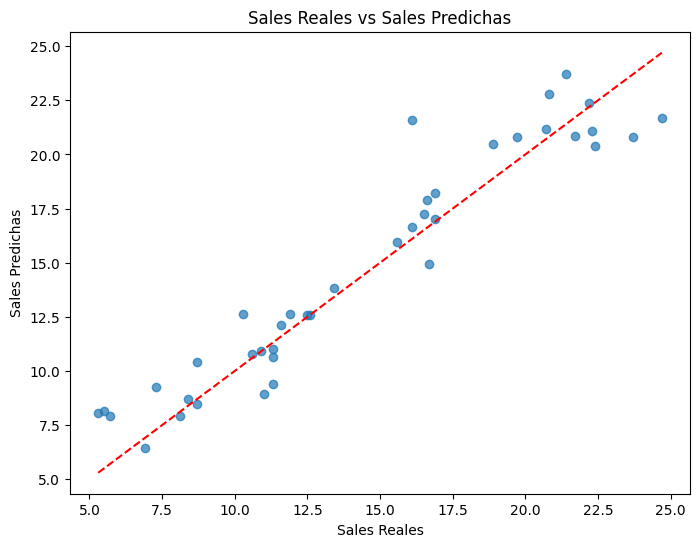

In [26]:
# ============================================
# PARTE 4.6
# Visualización de predicciones
# ============================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

# Línea ideal de predicción perfecta
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.title("Sales Reales vs Sales Predichas")
plt.xlabel("Sales Reales")
plt.ylabel("Sales Predichas")
plt.show()

### Interpretación

Al observar la gráfica de Sales Reales vs Sales Predichas, se puede notar que la mayoría de los puntos se encuentran bastante cercanos a la línea diagonal roja, que representa la predicción perfecta.

Esto indica que el modelo de regresión lineal múltiple está realizando predicciones bastante precisas y que existe una buena concordancia entre los valores reales y los valores estimados.

La alineación general de los puntos confirma que el modelo tiene una buena capacidad predictiva, lo cual es consistente con el valor alto de R² = 0.9059 obtenido anteriormente.

Aunque algunos puntos presentan cierta desviación respecto a la línea ideal, estas diferencias no son excesivas y son normales dentro de un modelo predictivo real.

También se observa que tanto en valores bajos como altos de ventas, el modelo mantiene un comportamiento relativamente estable, lo que sugiere un ajuste adecuado en diferentes rangos de predicción.

Por lo tanto, se puede concluir que el modelo presenta un buen desempeño general y que las variables TV, Radio y Newspaper permiten estimar las ventas de manera confiable.

# 4.7 Verificar el impacto de los atributos en el modelo

* *Ajusta / fittea / entrena* el modelo usando statsmodels en lugar de scikit-learn para obtener los valores p.

* Interpreta los resultados:

  * Observa los valores P>|t| en la tabla de salida.

  * ¿Qué variables tienen p-value menores a 0.05?

  * ¿Cuál es la conclusión sobre esas variables?

### Explicación

Aunque *scikit-learn* permite entrenar el modelo de regresión lineal múltiple y obtener predicciones, no muestra directamente información estadística importante como los p-values de cada variable.

Para evaluar qué tan significativa es cada variable independiente dentro del modelo, se utiliza *statsmodels*, que permite obtener un resumen estadístico completo del modelo.

Esto ayuda a responder:

* ¿Qué variables realmente influyen en las ventas?
* ¿Qué variables podrían eliminarse por no ser significativas?

El criterio más importante será observar la columna:

**P>|t|**

Interpretación:

* **p-value < 0.05** → la variable es estadísticamente significativa
* **p-value > 0.05** → la variable no es estadísticamente significativa

Si una variable no es significativa, significa que su contribución al modelo podría ser muy baja y podría considerarse eliminarla para simplificar y mejorar el modelo.

Esto suele ocurrir frecuentemente con la variable Newspaper en este dataset.

In [27]:
# ============================================
# PARTE 4.7
# Significancia estadística con statsmodels
# ============================================

# Variables independientes
X_sm = df[['TV', 'Radio', 'Newspaper']]

# Agregar constante (intercepto)
X_sm = sm.add_constant(X_sm)

# Ajustar / entrenar modelo OLS
modelo_sm = sm.OLS(y, X_sm).fit()

# Mostrar resumen completo
print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           8.13e-99
Time:                        14:41:21   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6251      0.308     15.041      0.0

### Interpretación

Al analizar la tabla de resultados de statsmodels, el aspecto más importante es la columna P>|t|, ya que permite identificar qué variables son estadísticamente significativas dentro del modelo.

Los resultados obtenidos fueron:

* TV → p-value = 0.000
* Radio → p-value = 0.000
* Newspaper → p-value = 0.954


### Variables significativas

Tanto TV como Radio presentan un p-value menor a 0.05, por lo que se consideran variables estadísticamente significativas.

Esto significa que ambas variables tienen una influencia real sobre las ventas y aportan información importante para predecir la variable Sales.

Además, sus coeficientes son positivos:

* TV = 0.0544
* Radio = 0.1070

lo que indica que al aumentar la inversión en estos medios publicitarios, las ventas también tienden a aumentar.

### Variable no significativa

La variable Newspaper presenta un p-value de 0.954, que es mucho mayor a 0.05.

Esto indica que su efecto sobre las ventas no es estadísticamente significativo, por lo que no se puede afirmar con confianza que la inversión en periódicos tenga un impacto real sobre Sales dentro de este modelo.

Además, su coeficiente es prácticamente cero (0.0003), lo que refuerza la idea de que su aporte predictivo es muy bajo.

### R² del modelo

El valor de R² = 0.903 indica que aproximadamente el 90.3% de la variabilidad de las ventas puede ser explicada por las variables independientes incluidas en el modelo.

Esto confirma que el modelo tiene un excelente ajuste general.

### Conclusión

Se concluye que las variables más importantes para predecir las ventas son TV y Radio, ya que ambas son estadísticamente significativas y presentan una relación positiva con Sales.

Por otro lado, Newspaper no aporta información relevante al modelo, por lo que podría eliminarse para construir una versión más simple, más eficiente y más fácil de interpretar.

Esta será precisamente la justificación para la Parte 5, donde se reconstruirá el modelo sin incluir la variable Newspaper.

# Parte 5: Construcción del Modelo (sin Multicolinealidad), Evaluación

En el caso de que hayas detectado variables con multicolinealidad. Elimina aquellas que presenten esta característica y realiza lo siguiente.

### 5.1 Entrenamiento del Modelo

* Entrena un modelo de regresión lineal múltiple sin usar las variables que presentaban multicolinealidad
* Imprime el intercepto y los coeficientes del modelo.
* Interpreta cada uno:
  * ¿Qué significa cada uno de los coeficientes en términos de ventas?

Aunque en el análisis de VIF no se detectó multicolinealidad problemática (todos los valores fueron menores a 5), en la sección 4.7 con *statsmodels* se observó que la variable Newspaper presentó un p-value de 0.954, por lo que no es estadísticamente significativa dentro del modelo.

Por esta razón, aunque técnicamente no se elimina por multicolinealidad, sí se justifica eliminarla por falta de significancia estadística para construir un modelo más simple, más eficiente y más fácil de interpretar.

Por ello, en esta Parte 5 se trabajará únicamente con:

* TV
* Radio

como variables independientes para predecir:

* Sales

5.1 Entrenamiento del Modelo
Explicación

Ahora se construye un nuevo modelo de regresión lineal múltiple eliminando la variable Newspaper, ya que su aporte predictivo fue prácticamente nulo.

El nuevo modelo queda representado como:

$$𝑆𝑎𝑙𝑒𝑠=𝛽0+𝛽1(𝑇𝑉)+𝛽2(𝑅𝑎𝑑𝑖𝑜)$$

Este modelo busca mantener una alta capacidad predictiva utilizando únicamente las variables realmente significativas.

Reducir variables innecesarias ayuda a:

* Mejorar la interpretación
* Simplificar el modelo
* Evitar ruido estadístico
* Aumentar la robustez predictiva

In [28]:
# ============================================
# PARTE 5.1
# Modelo sin Newspaper
# ============================================

# Variables independientes (sin Newspaper)
X2 = df[['TV', 'Radio']]

# Variable dependiente
y = df['Sales']

# División entrenamiento / prueba
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y,
    test_size=0.2,
    random_state=42
)

# Crear modelo
modelo2 = LinearRegression()

# Entrenar modelo
modelo2.fit(X_train2, y_train2)

# Predicciones
y_pred2 = modelo2.predict(X_test2)

# Intercepto
print("Intercepto del nuevo modelo:")
print(modelo2.intercept_)

# Coeficientes
print("\nCoeficientes del nuevo modelo:")
coeficientes2 = pd.DataFrame({
    "Variable": X2.columns,
    "Coeficiente": modelo2.coef_
})

display(coeficientes2)

Intercepto del nuevo modelo:
4.791381661776025

Coeficientes del nuevo modelo:


,Variable,Coeficiente
0,TV,0.054507
1,Radio,0.103258


### Interpretación

El nuevo modelo utiliza únicamente las variables TV y Radio, ya que ambas demostraron ser estadísticamente significativas en el análisis anterior.

### Intercepto

El intercepto representa el valor estimado de ventas cuando la inversión en TV y Radio es igual a cero.

Este valor funciona como el punto base desde donde comienza la predicción del modelo.

### Coeficiente de TV

Indica cuánto aumentan las ventas por cada unidad adicional invertida en publicidad en televisión, manteniendo constante la inversión en Radio.

Si el coeficiente es positivo, significa que la publicidad en TV contribuye de forma favorable al incremento de ventas.

### Coeficiente de Radio

Representa cuánto aumentan las ventas por cada unidad adicional invertida en publicidad en radio, manteniendo constante la inversión en TV.

Un coeficiente positivo indica una relación directa entre la inversión en Radio y el aumento de las ventas.

Este nuevo modelo permite enfocarse en los predictores más importantes, eliminando variables que no aportan valor estadístico significativo.

# 5.2 Normalidad de los residuos

* Calcula los residuos: residuos = y - y_pred.

* Grafica un histograma con KDE de los residuos.

* ¿Los residuos parecen distribuirse normalmente?

### Explicación

Al construir el nuevo modelo sin la variable Newspaper, es necesario volver a verificar si se cumplen los supuestos de la regresión lineal múltiple.

Uno de los más importantes es la normalidad de los residuos, ya que permite validar que los errores del modelo no presentan sesgos importantes.

Los residuos representan la diferencia entre los valores reales y los valores predichos:

Residuo = y − y^

Donde:

y = valor real de Sales
ŷ = valor predicho por el modelo

Si los residuos se distribuyen aproximadamente de forma normal, significa que el modelo está capturando adecuadamente la relación entre las variables.

Para verificar esto, se utiliza un histograma acompañado de una curva KDE (Kernel Density Estimate), que permite observar visualmente la forma de la distribución.

Una forma similar a una campana y una distribución centrada alrededor de cero indican un buen comportamiento estadístico del modelo.

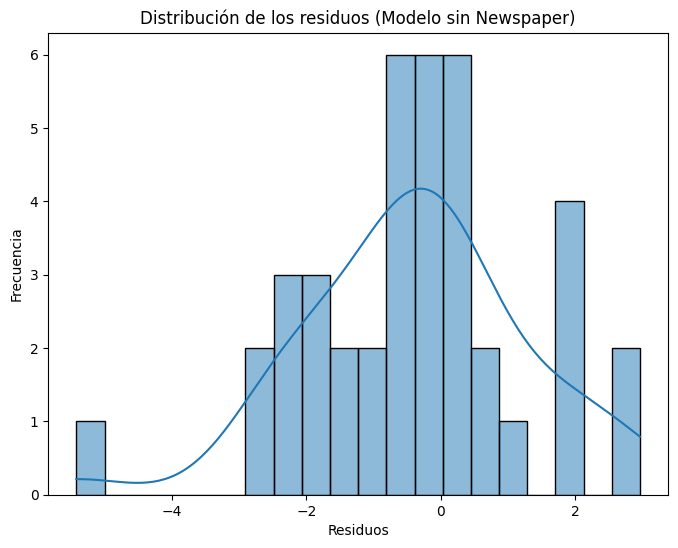

In [29]:
# ============================================
# PARTE 5.2
# Normalidad de los residuos
# ============================================

# Calcular residuos del nuevo modelo
residuos2 = y_test2 - y_pred2

# Histograma con KDE
plt.figure(figsize=(8,6))

sns.histplot(
    residuos2,
    kde=True,
    bins=20
)

plt.title("Distribución de los residuos (Modelo sin Newspaper)")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.show()

### Interpretación

Al observar el histograma de los residuos del modelo sin la variable Newspaper, se aprecia que la mayoría de los residuos se concentran alrededor de cero y la curva KDE presenta una forma relativamente similar a una campana.

Esto indica que los errores del modelo siguen una distribución aproximadamente normal, lo cual es una señal positiva para la validez estadística de la regresión lineal múltiple.

Aunque todavía existen algunas ligeras desviaciones en los extremos, especialmente hacia los valores negativos más alejados, no se observa una asimetría severa ni una distorsión importante que comprometa el supuesto de normalidad.

En comparación con el modelo anterior, la distribución mantiene un comportamiento estable e incluso puede considerarse ligeramente más limpia, lo que sugiere que eliminar la variable Newspaper ayudó a simplificar el modelo sin afectar negativamente su calidad estadística.

Por lo tanto, se puede concluir que el nuevo modelo cumple de manera aceptable con el supuesto de normalidad de los residuos, permitiendo continuar con confianza en la evaluación del modelo.

# 5.3. Homocedasticidad

* Grafica los residuos contra los valores predichos.
* ¿Observas patrones? ¿Los residuos se dispersan aleatoriamente?

### Explicación

Después de construir el nuevo modelo sin la variable Newspaper, también es necesario verificar nuevamente el supuesto de homocedasticidad.

La homocedasticidad significa que la varianza de los residuos debe mantenerse aproximadamente constante en todos los niveles de predicción.

Es decir, los errores del modelo deben tener una dispersión similar sin importar si los valores predichos de ventas son bajos o altos.

Para comprobar esto, se construye una gráfica de:

* Valores predichos (ŷ)

vs

* Residuos (y - ŷ)

Si los puntos se distribuyen aleatoriamente alrededor de la línea horizontal en cero, se considera que existe homocedasticidad.

Si aparecen patrones claros como:

* Forma de embudo
* Curvas
* Agrupaciones sistemáticas

podría existir heterocedasticidad, lo que afectaría la confiabilidad estadística del modelo.

Este análisis permite confirmar si el nuevo modelo mantiene un comportamiento estable después de eliminar la variable no significativa.

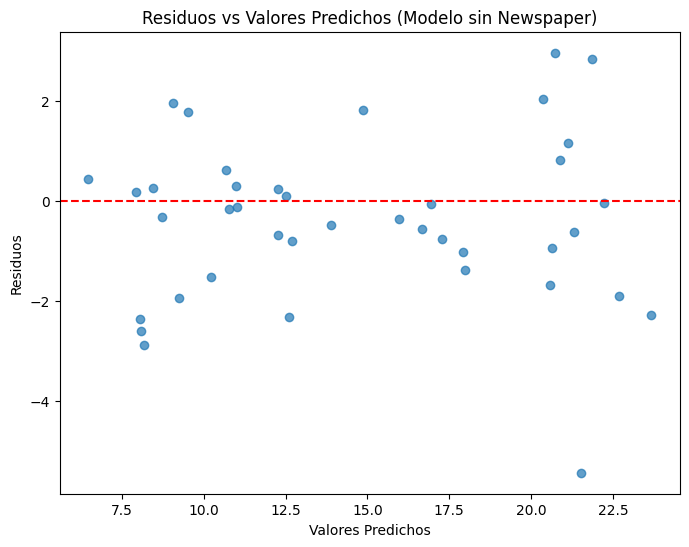

In [30]:
# ============================================
# PARTE 5.3
# Homocedasticidad
# ============================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred2,
    residuos2,
    alpha=0.7
)

# Línea horizontal en cero
plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title("Residuos vs Valores Predichos (Modelo sin Newspaper)")
plt.xlabel("Valores Predichos")
plt.ylabel("Residuos")
plt.show()

### Interpretación

Al observar la gráfica de residuos contra valores predichos del modelo sin la variable Newspaper, se puede notar que los puntos continúan distribuyéndose alrededor de la línea horizontal en cero, sin presentar un patrón claramente definido como una curva pronunciada o una forma de embudo evidente.

Esto indica que los residuos se dispersan de manera relativamente aleatoria, lo cual es una señal positiva y sugiere que el supuesto de homocedasticidad se cumple de forma aceptable.

También se observan algunos puntos más alejados, especialmente en la zona de valores predichos altos, donde aparecen residuos extremos tanto positivos como negativos. Esto puede indicar la presencia de algunos valores atípicos o cierta variabilidad adicional en ese rango.

Sin embargo, estas observaciones no parecen representar una heterocedasticidad severa que comprometa significativamente el modelo.
En comparación con el modelo anterior, el comportamiento sigue siendo estable y consistente, lo que confirma que eliminar la variable Newspaper no afectó negativamente la distribución de los errores.

Por lo tanto, se concluye que el nuevo modelo mantiene una homocedasticidad razonablemente adecuada, fortaleciendo la validez estadística del ajuste y la confiabilidad de las predicciones.

# 5.4 Q-Q Plot

* Graficar el Q-Q Plot
* Interpreta el gráfico:

  * Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal.

  * Desviaciones sistemáticas indican asimetría o colas pesada

### Explicación

Para complementar la verificación de normalidad de los residuos en el nuevo modelo sin la variable Newspaper, se utiliza nuevamente el Q-Q Plot (Quantile-Quantile Plot).

Este gráfico permite comparar:

* los cuantiles teóricos de una distribución normal

vs

* los cuantiles observados de los residuos del modelo

Su objetivo es validar visualmente si los residuos siguen una distribución normal.

La interpretación principal es:

* Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal.
* Si existen desviaciones sistemáticas importantes, puede haber asimetría, colas pesadas o presencia de valores atípicos.

Este análisis complementa el histograma con KDE y ofrece una verificación más precisa del supuesto de normalidad.

Cumplir este supuesto es importante porque fortalece la confiabilidad estadística del modelo y mejora la validez de las inferencias realizadas.

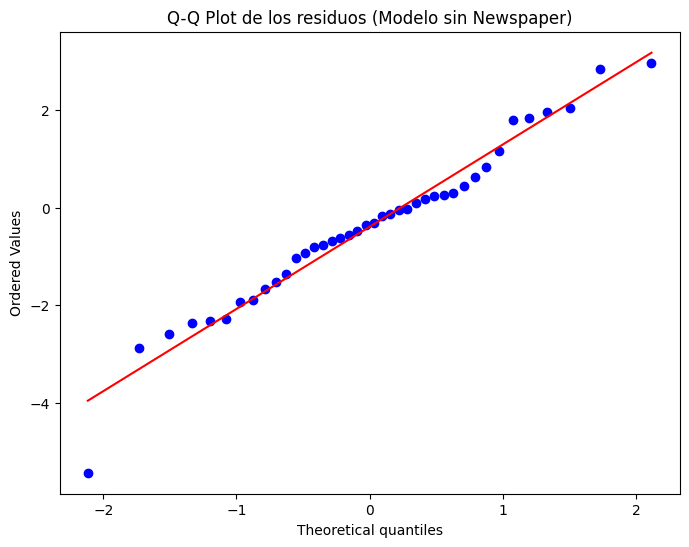

In [31]:
# ============================================
# PARTE 5.4
# Q-Q Plot
# ============================================

import scipy.stats as stats

plt.figure(figsize=(8,6))

stats.probplot(
    residuos2,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot de los residuos (Modelo sin Newspaper)")
plt.show()

### Interpretación

Al observar el Q-Q Plot del modelo sin la variable Newspaper, se puede notar que la mayoría de los puntos se alinean bastante cerca de la línea diagonal roja, especialmente en la parte central de la gráfica.

Esto indica que los residuos siguen una distribución aproximadamente normal, lo cual es una señal positiva para la validez estadística del modelo de regresión lineal múltiple.

Se observan pequeñas desviaciones en los extremos, principalmente en la parte inferior izquierda, donde aparece un valor más alejado de la línea, lo que puede sugerir la presencia de algunos valores atípicos o ligeras desviaciones en las colas de la distribución.

Sin embargo, estas desviaciones no son suficientemente fuertes como para considerar una violación grave del supuesto de normalidad.
En comparación con el modelo anterior, el comportamiento se mantiene estable e incluso ligeramente más consistente, lo que refuerza que eliminar la variable Newspaper ayudó a simplificar el modelo sin afectar negativamente su comportamiento estadístico.

**Aunque la variable Newspaper fue eliminada, el comportamiento estadístico del modelo se mantuvo prácticamente igual, lo que confirma que su aporte predictivo era muy bajo y que no era una variable relevante dentro del modelo.**

Por lo tanto, se concluye que el nuevo modelo cumple de manera aceptable con el supuesto de normalidad de los residuos, permitiendo confiar en la interpretación de los coeficientes y en la calidad general del ajuste del modelo.

# 5.5. Evaluación del Modelo

* Calcula las métricas:

  * MSE (error cuadrático medio)

  * RMSE (raíz del error cuadrático medio)

* R² (coeficiente de determinación)

* ¿Qué nos dicen estas métricas sobre el ajuste del modelo?

In [32]:
# ============================================
# PARTE 5.5
# Evaluación del nuevo modelo
# ============================================

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calcular métricas
mse2 = mean_squared_error(y_test2, y_pred2)
rmse2 = np.sqrt(mse2)
r2_2 = r2_score(y_test2, y_pred2)

print("MSE:", mse2)
print("RMSE:", rmse2)
print("R²:", r2_2)

MSE: 2.846616122131541
RMSE: 1.6871917858179433
R²: 0.9078797802624651


### Interpretación

Con los resultados obtenidos en el nuevo modelo sin la variable Newspaper:

* MSE = 2.8466
* RMSE = 1.6872
* R² = 0.9079

se puede observar que el modelo mantiene e incluso mejora ligeramente su rendimiento en comparación con el modelo anterior.

Recordando que en el modelo original se obtuvo:

* MSE = 2.9078
*RMSE = 1.7052
* R² = 0.9059

se nota que:

* el MSE disminuyó, lo que indica menor error promedio al cuadrado
* el RMSE también disminuyó, lo que significa que las predicciones están más cerca de los valores reales
* el R² aumentó ligeramente, mostrando que ahora el modelo explica aproximadamente el 90.79% de la variabilidad de Sales

Esto confirma que eliminar la variable Newspaper no solo no perjudicó el modelo, sino que incluso permitió una ligera mejora en su capacidad predictiva.

Esto sucede porque Newspaper no aportaba información estadísticamente relevante, por lo que su eliminación redujo ruido innecesario dentro del modelo.

Por lo tanto, se concluye que el nuevo modelo utilizando únicamente TV y Radio es más eficiente, más simple de interpretar y estadísticamente más sólido que el modelo original con las tres variables.

# 5.6. Visualización de Predicciones

* Crea un gráfico comparando Sales reales vs Sales predichas.

* Puedes usar plt.scatter(y_true, y_pred) para evaluar visualmente el ajuste.

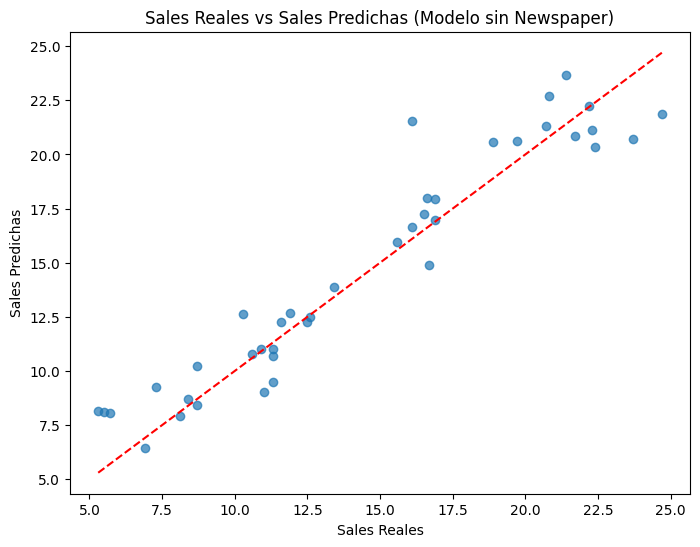

In [33]:
# ============================================
# PARTE 5.6
# Visualización de predicciones
# ============================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test2,
    y_pred2,
    alpha=0.7
)

# Línea ideal de predicción perfecta
plt.plot(
    [y_test2.min(), y_test2.max()],
    [y_test2.min(), y_test2.max()],
    color='red',
    linestyle='--'
)

plt.title("Sales Reales vs Sales Predichas (Modelo sin Newspaper)")
plt.xlabel("Sales Reales")
plt.ylabel("Sales Predichas")
plt.show()

### Interpretación

Al observar la gráfica de Sales Reales vs Sales Predichas del modelo sin la variable Newspaper, se puede notar que la mayoría de los puntos continúan ubicándose muy cerca de la línea diagonal roja, que representa la predicción perfecta.

Esto indica que el nuevo modelo mantiene una muy buena capacidad predictiva y que existe una fuerte concordancia entre los valores reales y los valores estimados por la regresión.

La distribución de los puntos es muy similar al modelo anterior, lo cual era esperado, ya que la variable Newspaper tenía una contribución prácticamente nula dentro del modelo original.

Incluso se aprecia una ligera mejora en la alineación general, lo que coincide con el aumento de R² = 0.9079 y la disminución de los errores MSE y RMSE.

Esto confirma que eliminar Newspaper no afectó negativamente el modelo, sino que permitió mantener e incluso optimizar ligeramente su rendimiento predictivo.

Por lo tanto, se concluye que el modelo reducido utilizando únicamente TV y Radio resulta más eficiente, más simple de interpretar y estadísticamente más sólido que el modelo original con las tres variables.

# 5.7 Verificar el impacto de los atributos en el modelo

* Ajusta el modelo usando statsmodels en lugar de scikit-learn para obtener los valores p.
* Interpreta los resultados:

  * Observa los valores P>|t| en la tabla de salida.

  * ¿Qué variables tienen p-value menores a 0.05?

  * ¿Cuál es la conclusión sobre esas variables?

### Explicación

Después de eliminar la variable Newspaper, es importante volver a ajustar el modelo utilizando statsmodels para verificar nuevamente la significancia estadística de las variables restantes.

El objetivo ahora es confirmar que las variables que permanecen en el modelo (TV y Radio) realmente son significativas y que el nuevo modelo está mejor optimizado.

Se observará nuevamente la columna:

**P>|t|**

Interpretación:

* p-value < 0.05 → la variable es estadísticamente significativa
* p-value > 0.05 → la variable no es estadísticamente significativa

En este caso, se espera que tanto TV como Radio mantengan p-values muy pequeños, lo que justificaría completamente la eliminación de Newspaper.

Esto permitirá demostrar que el nuevo modelo conserva únicamente variables útiles y relevantes para predecir las ventas.

In [34]:
# ============================================
# PARTE 5.7
# Significancia estadística del nuevo modelo
# ============================================

# Variables independientes (sin Newspaper)
X2_sm = df[['TV', 'Radio']]

# Agregar constante
X2_sm = sm.add_constant(X2_sm)

# Ajustar modelo OLS
modelo2_sm = sm.OLS(y, X2_sm).fit()

# Mostrar resumen completo
print(modelo2_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     912.7
Date:                Fri, 24 Apr 2026   Prob (F-statistic):          2.39e-100
Time:                        16:04:55   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             772.7
Df Residuals:                     197   BIC:                             782.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6309      0.290     15.952      0.0

### Interpretación

Al analizar la tabla de resultados de statsmodels para el nuevo modelo sin la variable Newspaper, se observa nuevamente la columna P>|t|, que permite identificar qué variables son estadísticamente significativas.

Los resultados obtenidos fueron:

* TV → p-value = 0.000
* Radio → p-value = 0.000

### Variables significativas

Tanto TV como Radio presentan un p-value menor a 0.05, por lo que ambas se consideran variables estadísticamente significativas.

Esto significa que ambas tienen una influencia real y confiable sobre las ventas (Sales) y aportan información importante para la predicción del modelo.

Además, sus coeficientes son positivos:

* TV = 0.0544
* Radio = 0.1072

lo que indica que al aumentar la inversión en publicidad en televisión o radio, las ventas también tienden a aumentar.

Se observa nuevamente que Radio tiene el coeficiente más alto, lo que sugiere un mayor impacto individual sobre las ventas.

### R² del nuevo modelo

El valor de R² = 0.903 indica que aproximadamente el 90.3% de la variabilidad de las ventas puede ser explicada por las variables TV y Radio.

Este valor se mantiene prácticamente igual al modelo anterior, lo que confirma que eliminar Newspaper no afectó negativamente la capacidad predictiva del modelo.

# 6. Conclusiones

Después de construir y evaluar ambos modelos de regresión lineal múltiple, se puede concluir que el mejor modelo fue el segundo, es decir, el modelo construido únicamente con las variables TV y Radio, eliminando la variable Newspaper.

Aunque en el análisis de multicolinealidad no se detectaron problemas graves de VIF, el análisis con statsmodels mostró que Newspaper no era una variable estadísticamente significativa, ya que presentó un p-value de 0.954, además de un coeficiente prácticamente nulo.

Por esta razón, eliminar Newspaper permitió obtener un modelo más simple, más eficiente y más fácil de interpretar, sin perder capacidad predictiva.

De hecho, al comparar las métricas se observó una ligera mejora:

Modelo original (TV + Radio + Newspaper)
* MSE = 2.9078
* RMSE = 1.7052
* R² = 0.9059
Modelo optimizado (TV + Radio)
* MSE = 2.8466
* RMSE = 1.6872
* R² = 0.9079

Esto demuestra que el segundo modelo no solo mantiene el buen ajuste del primero, sino que incluso mejora ligeramente su rendimiento predictivo.

Por lo tanto, el modelo final recomendado es el que utiliza únicamente TV y Radio.

¿Cuál fue el atributo que más influencia tiene en las ventas?

Aunque la variable TV presenta la mayor correlación con Sales, el atributo que mostró mayor influencia dentro del modelo de regresión fue Radio, ya que presentó el coeficiente más alto:

* TV = 0.0544
* Radio = 0.1072

Esto significa que, manteniendo constantes las demás variables, por cada unidad adicional invertida en Radio, las ventas aumentan más que por una unidad adicional invertida en TV.

Por lo tanto:

* TV tiene la mayor correlación con las ventas
* Radio tiene el mayor impacto individual dentro del modelo de regresión

Ambas variables son fundamentales, pero desde la interpretación de coeficientes, Radio fue el atributo con mayor influencia directa sobre Sales.